<hr style="border:1px solid #808080">                                                                                                                   </hr>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>Ayudantía 2 - Python y Numpy para Computación científica</b>                                                                           </h1>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>IBM2020 Introducción a la Biomecánica</b>                                                                           </h1>
<p style=padding:0;margin:0>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;"> Profesor - <span style="color:#dbdbdb;text-align:center;"><b>Daniel Hurtado</b></span></h3>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;">Ayudantes - <span style="color:#dbdbdb;text-align:center;"><b>Vicente Zúñiga, Clio Kipreos</b></span></h3> 
</p>
<h4 style="color:#dbdbdb;text-align:center;margin:0;padding:0;">Instituto de Ingeniería Biológica y Médica<br>Escuela de Ingeniería<br>  Pontificia Universidad Católica de Chile <br></h4>
<hr style="border:1px solid #808080">                                                                                                                   </hr>

## Introducción
La biomecánica estudia el comportamiento mecánico de los tejidos blandos, usualmente sometidos a grandes deformaciones, y que presentan relaciones no lineales entre tensión y deformación. Para describir cuantitativamente este comportamiento, es necesario saber definir un dominio $\Omega$ que represente el cuerpo a estudiar, cómo aplicar deformaciones, graficar sus tensiones y extraer resultados que se puedan entender fácilmente. 

En esta ayudantía cubriremos las herramientas y librerías de Python necesarias para este curso y para resolver problemas de computación científica en general, y haremos un ejercicio aplicado de cambio de coordenadas.

## Creación de dominios y transformación de coordenadas
Para mostrar la configuración inicial y actual de un determinado dominio, es necesario definirlo y aplicarle una función $\varphi$, que conocemos como el **mapeo de deformación**. Usaremos la función `numpy.meshgrid` para crear coordenadas con las que podremos trabajar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
N = 30

# Genera los valores de R y Theta de forma independiente
R = np.linspace(1, 5, N)
Theta = np.linspace(0, (7/4)*np.pi, 2*N)


# Genera nuestro espacio de coordenadas polares
RR, TT = np.meshgrid(R, Theta) 

print(R.shape)
print(Theta.shape)

print(RR.shape)
print(TT.shape)

(30,)
(60,)
(60, 30)
(60, 30)


Mostramos nuestro dominio en ambos sistemas de coordenadas.

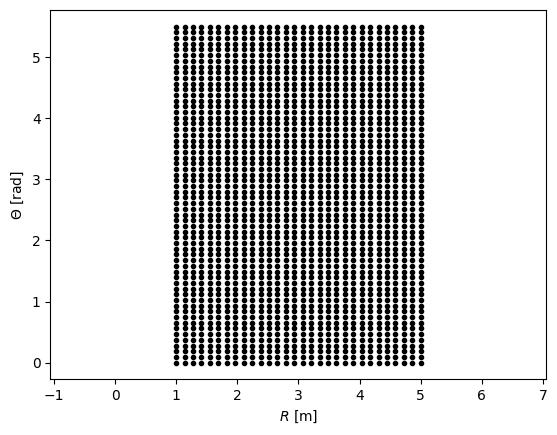

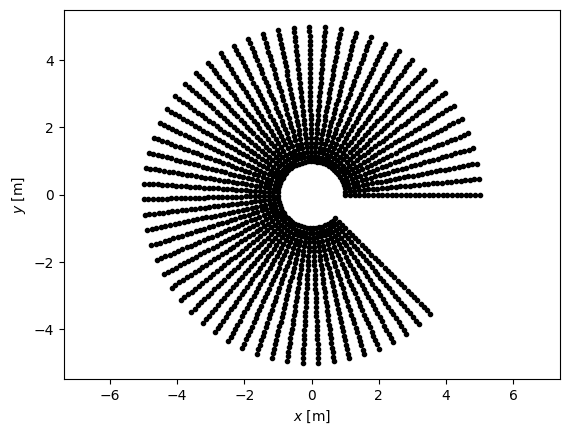

In [12]:
plt.figure()
plt.plot(RR, TT, '.', color='black')
plt.axis('equal')
plt.xlabel(r"$R$ [m]")
plt.ylabel(r"$\Theta$ [rad]")
plt.show()


XX = RR*np.cos(TT)
YY = RR*np.sin(TT)


plt.figure()
plt.plot(XX, YY, '.', color='black')
plt.axis('equal')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$y$ [m]")
plt.show()

Ahora aplicamos nuestro mapeo de deformación y graficamos. 

Nótese que cada operación se realiza sobre nuestro dominio `(aa, bb)` y no sobre los arrays independientes `(a, b)`.

In [13]:
def phi(R, T):
    r = R**2 / 8
    t = T / 10
    return r, t


rr, tt = phi(RR,TT)

xx = rr*np.cos(tt)
yy = rr*np.sin(tt)

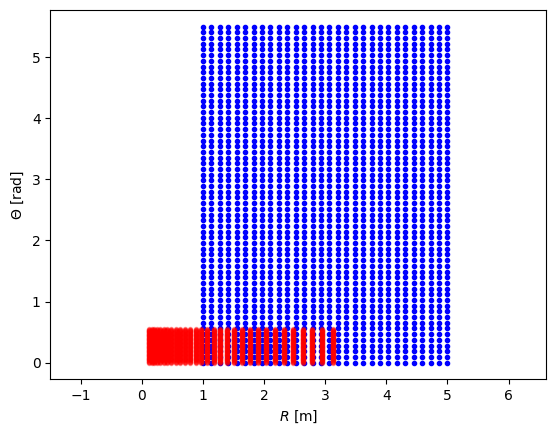

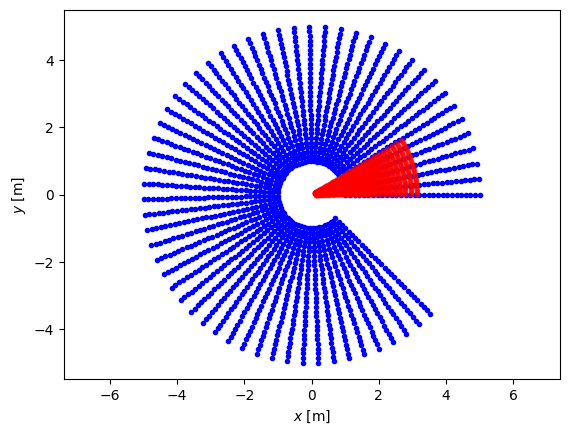

In [14]:
plt.figure()
plt.plot(RR, TT, '.', color='blue', alpha=1)
plt.plot(rr, tt, '.', color='red', alpha=1/3)
plt.axis('equal')
plt.xlabel(r"$R$ [m]")
plt.ylabel(r"$\Theta$ [rad]")
plt.show()


plt.figure()
plt.plot(XX, YY, '.', color='blue', alpha=1)
plt.plot(xx, yy, '.', color='red', alpha=1/3)
plt.axis('equal')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$y$ [m]")
plt.show()

## Ejercicio: Cambio de coordenadas en estado de tensiones planas

Ahora supongamos que tenemos sobre un cuerpo un estado de tensiones planas $\sigma$, que se representa en un sistema de coordenadas $\{X, Y, Z\}$ como:

$$\sigma_{XYZ} = \begin{pmatrix}
\sigma_1 & \tau & 0\\
\tau & \sigma_2 & 0\\
0 & 0 & \sigma_3
\end{pmatrix} = 
\begin{pmatrix}
12 & 7 & 0\\
7 & 4 & 0\\
0 & 0 & 5
\end{pmatrix} 
$$

Nos interesa saber cómo cambian los valores de las tensiones cuando rotamos nuestro sistema de coordenadas en un ángulo arbitrario $\theta$. 

Esta transformación se representa con

$$
\sigma' = Q \sigma Q^\top, \qquad 
Q = \begin{pmatrix}
\cos\theta & \sin\theta & 0\\
-\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}
$$

Donde $Q$ es la matriz de rotación en el plano XY para un ángulo $\theta$.


--- 

1. Grafique el valor de las componentes $\sigma_1, \tau_{12}, \sigma_2$ para cada valor de $\theta$.

2. Determine de numérica, para qué valor de $\theta$ hay tensión de corte nula y luego máxima.

3. Desarrolle una expresión analítica para las componentes del tensor de tensiones.

---


### 1. Solución numérica

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [31]:
N = 1000

sigma_11 = 12
sigma_12 = 0
sigmma_22 = 4

thetas = np.linspace(0, np.pi, N)

s = np.array(
    [
    [sigma_11, sigma_12],
    [sigma_12, sigmma_22]
    ]
)


In [18]:
def Q(theta):
    return np.array(
        [
            [np.cos(theta), np.sin(theta)],
            [-np.sin(theta), np.cos(theta)]
        ]
    )


In [32]:
# Forma 1: iterar por cada valor de theta
s_thetas = []
for theta in thetas:
    sigma_theta = Q(theta) @ s @ Q(theta).T
    s_thetas.append(sigma_theta)

s_thetas = np.array(s_thetas)

print(s_thetas.shape) # (N, 2, 2)


(1000, 2, 2)


In [22]:
Q_0 = Q(thetas)
print(Q_0.shape)

Q_all = np.moveaxis(Q_0, -1, 0)
print(Q_all.shape) # (N, 2, 2)

QT_all = np.transpose(Q_all, (0, 2, 1))

(2, 2, 1000)
(1000, 2, 2)


In [33]:
s_thetas_all = Q_all @ s @ QT_all

In [25]:
print(np.allclose(s_thetas, s_thetas_all))

np.set_printoptions(precision=16)

print(s_thetas[165])
print(s_thetas_all[165])

True
[[16.06148037671049    0.1119559552308628]
 [ 0.1119559552308629 -0.0614803767104928]]
[[16.06148037671049    0.1119559552308624]
 [ 0.1119559552308627 -0.0614803767104927]]


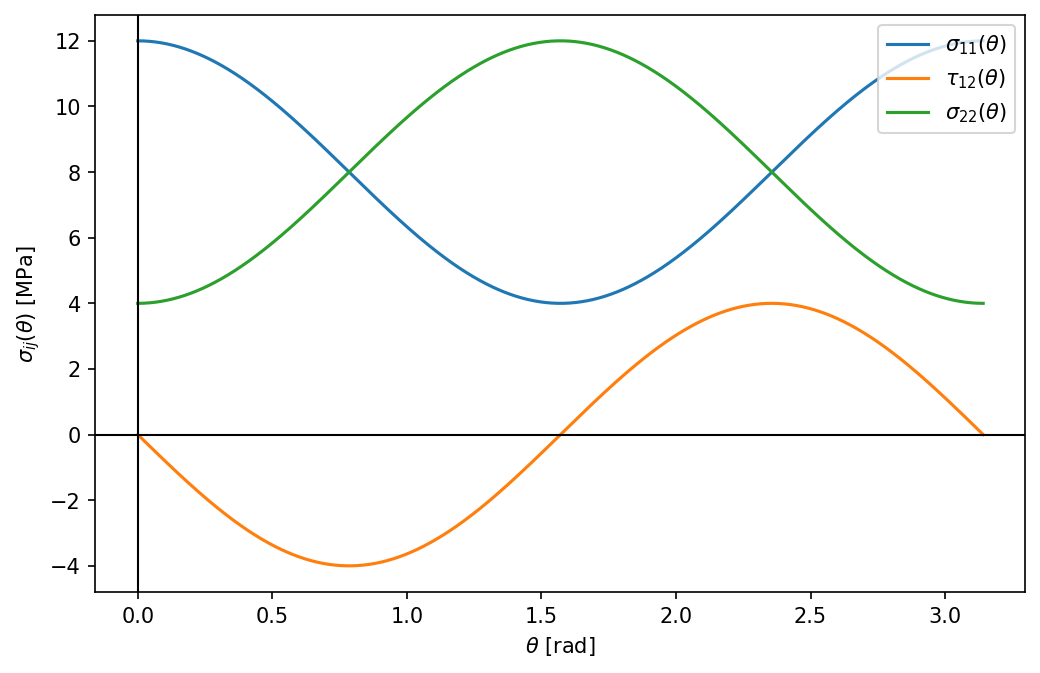

In [34]:
sigmas_1 = s_thetas[:, 0, 0]
taus_12 = s_thetas[:,0,1]
sigmas_2 = s_thetas[:,1,1]


fig, ax = plt.subplots(figsize=(8,5), dpi=150)
ax.plot(thetas, sigmas_1, label=r'$\sigma_{11}(\theta)$')
ax.plot(thetas, taus_12, label=r'$\tau_{12}(\theta)$')
ax.plot(thetas, sigmas_2, label=r'$\sigma_{22}(\theta)$')

ax.axhline(0, color='black', lw=1, ls='solid')
ax.axvline(0, color='black', lw=1, ls='solid')
ax.set_xlabel(r'$\theta$ [rad]')
ax.set_ylabel(r'$\sigma_{ij}(\theta)$ [MPa]')

ax.legend(loc='upper right')

plt.show()

<!-- ### 2. Valores de $\theta$ para corte máximo y nulo -->

Podemos usar la función `np.argmin` y `np.argmax` para buscar los índices en donde se encuentran los valores mínimo y máximo, respectivamente.

In [ ]:
theta_max_sigma = thetas[np.argmax(sigmas_1)]
theta_max_tau = thetas[np.argmax(taus_12)]
theta_min_tau = thetas[np.argmin(taus_12)]


print(theta_max_sigma, end="\n\n")
print(theta_max_tau , end="\n\n")
print(theta_min_tau , end="\n\n")

0.5251711442937892

2.880579450138389

1.3113554920389827



Con esto, podemos ver qué valores toma el tensor de tensiones para cada ángulo

In [28]:
np.set_printoptions(precision=4)

s_max_sigma = Q(theta_max_sigma) @ s @ Q(theta_max_sigma).T
s_max_tau = Q(theta_max_tau) @ s @ Q(theta_max_tau).T
s_min_tau = Q(theta_min_tau) @ s @ Q(theta_min_tau).T

print(s_max_sigma, end="\n\n")
print(s_max_tau, end="\n\n")
print(s_min_tau, end="\n\n")

[[ 1.6062e+01  1.0545e-02]
 [ 1.0545e-02 -6.2251e-02]]

[[7.9768 8.0622]
 [8.0622 8.0232]]

[[ 7.9979 -8.0623]
 [-8.0623  8.0021]]



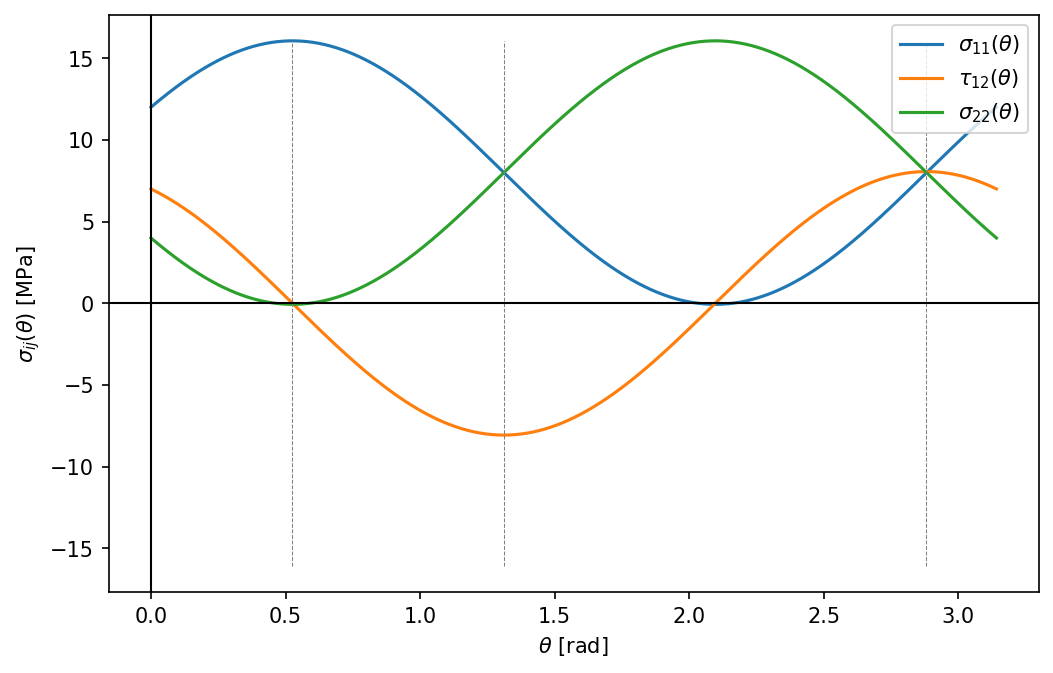

In [29]:
fig, ax = plt.subplots(figsize=(8,5), dpi=150)
ax.plot(thetas, sigmas_1, label=r'$\sigma_{11}(\theta)$')
ax.plot(thetas, taus_12, label=r'$\tau_{12}(\theta)$')
ax.plot(thetas, sigmas_2, label=r'$\sigma_{22}(\theta)$')

max_tension = np.max(np.abs(s_thetas))
ax.vlines([theta_max_sigma, theta_max_tau, theta_min_tau], -max_tension, max_tension, color='gray', lw=0.5, ls='--')

ax.axhline(0, color='black', lw=1, ls='solid')
ax.axvline(0, color='black', lw=1, ls='solid')
ax.set_xlabel(r'$\theta$ [rad]')
ax.set_ylabel(r'$\sigma_{ij}(\theta)$ [MPa]')

ax.legend(loc='upper right')

plt.show()


### 3. Solución analítica

Datos:
$$
\sigma_{XYZ} = \begin{pmatrix}
\sigma_1 & \tau_{12} & 0\\
\tau_{21} & \sigma_2 & 0\\
0 & 0 & \sigma_3
\end{pmatrix}, \qquad
Q = \begin{pmatrix}
\cos\theta & \sin\theta & 0\\
-\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}, \qquad
\sigma = \sigma^\top
$$

$$
\sigma' = Q \sigma Q^\top
$$
Se expande la transformació de coordenadas y se resuelve la multiplicación de matrices:
$$
\sigma' = 
\begin{pmatrix}
\cos\theta & \sin\theta & 0\\
-\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
\sigma_1 & \tau_{12} & 0\\
\tau_{21} & \sigma_2 & 0\\
0 & 0 & \sigma_3
\end{pmatrix}
\begin{pmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}
$$

$$
\sigma' = 
\begin{pmatrix}
\sigma_1\cos\theta + \tau_{12}\sin\theta & \tau_{12}\cos\theta + \sigma_2\sin\theta & 0\\
-\sigma_1\sin\theta + \tau_{12}\cos\theta & -\tau_{12}\sin\theta + \sigma_2\cos\theta & 0\\
0 & 0 & \sigma_3
\end{pmatrix}
\begin{pmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}
$$

$$
\sigma' = 
\begin{pmatrix}
\sigma_1\cos\theta\cos\theta + \tau_{12}\sin\theta\cos\theta + \tau_{12}\cos\theta\sin\theta + \sigma_2\sin\theta\sin\theta & -\sigma_1\cos\theta\sin\theta - \tau_{12}\sin\theta\sin\theta + \tau_{12}\cos\theta\cos\theta + \sigma_2\sin\theta\cos\theta & 0\\
-\sigma_1\sin\theta\cos\theta + \tau_{12}\cos\theta\cos\theta + \tau_{12}\sin\theta\sin\theta + \sigma_2\cos\theta\sin\theta & \sigma_1\sin\theta\sin\theta - \tau_{12}\cos\theta\sin\theta - \tau_{12}\sin\theta\cos\theta + \sigma_2\cos\theta\cos\theta & 0\\
0 & 0 & \sigma_3
\end{pmatrix}
$$

$$
\sigma' = 
\begin{pmatrix}
\sigma_1\cos^2\theta + 2\tau_{12}\sin\theta\cos\theta + \sigma_2\sin^2\theta & \tau_{12}(\cos^2\theta-\sin^2\theta) + (\sigma_2-\sigma_1)\sin\theta\cos\theta & 0\\
 \tau_{12}(\cos^2\theta-\sin^2\theta) + (\sigma_2-\sigma_1)\sin\theta\cos\theta & \sigma_1\sin^2\theta - 2\tau_{12}\cos\theta\sin\theta + \sigma_2\cos^2\theta & 0\\
0 & 0 & \sigma_3
\end{pmatrix}
$$

Ahora, aplicamos las siguientes identidades trigonométricas para reducir la expresión:
$$\cos(2\theta) = \cos^2\theta - \sin^2\theta$$
$$\sin(2\theta) = 2\sin\theta\cos\theta$$

$$
\sigma' = 
\begin{pmatrix}
\frac{\sigma_1+\sigma_2}{2}+\frac{\sigma_1-\sigma_2}{2}\cos(2\theta) + \tau_{12}\sin(2\theta) & -\frac{\sigma_1-\sigma_2}{2}\sin(2\theta) + \tau_{12}\cos(2\theta) & 0\\
-\frac{\sigma_1-\sigma_2}{2}\sin(2\theta) + \tau_{12}\cos(2\theta) & \frac{\sigma_1+\sigma_2}{2}-\frac{\sigma_1-\sigma_2}{2}\cos(2\theta) - \tau_{12}\sin(2\theta) & 0\\
0 & 0 & \sigma_3
\end{pmatrix}
$$

Como se puede apreciar, se llega a las mismas ecuaciones que luego se representan en el círculo de Mohr.

$$
\sigma'_1
=
\frac{\sigma_1+\sigma_2}{2}+\frac{\sigma_1-\sigma_2}{2}\cos(2\theta) + \tau_{12}\sin(2\theta)\\
$$
$$
 \tau'_{12}
=
-\frac{\sigma_1-\sigma_2}{2}\sin(2\theta) + \tau_{12}\cos(2\theta)\\
$$
$$
\sigma'_2
=
\frac{\sigma_1+\sigma_2}{2}-\frac{\sigma_1-\sigma_2}{2}\cos(2\theta) - \tau_{12}\sin(2\theta)
$$